# Anomaly Analysis and Validation

This notebook analyses and validates the anomaly detection results generated by
the Isolation Forest and Local Outlier Factor models in the training pipeline. The analysis focuses on the distribution and interpretation of
anomaly scores, agreement between models, characteristics of the detected
observations, comparison with business-rule flags, and the identification of
representative anomalous listings.

**Scope:**
- No models are trained here: all scores/flags come from the previous training notebook's  outputs.
- Results are loaded from `model_results_full.csv`.
- Isolation Forest and LOF outputs are analysed individually and jointly.
- Agreement between both models is quantified.
- Detected anomalies are characterised (property type, region, numeric profile).
- Model outputs are contrasted against business-rule flags (external reference,
  not ground truth).
- The most relevant / representative cases are examined individually.
- Reusable tables and figures are exported for the TFM write-up.

**Convention reminder:** `if_anomaly` and `lof_anomaly` follow
scikit-learn's convention: **`-1` = anomaly, `1` = normal**. This notebook builds
boolean helper columns (`is_if_anomaly`, `is_lof_anomaly`) early on to avoid any
ambiguity in the rest of the analysis.


## 1. Load results and verify reproducibility

### 1.1 Imports

In [1]:
import json
from pathlib import Path
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("default")

OUTPUT_DIR = Path("outputs")
FIG_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully")


Libraries imported successfully


### 1.2 Load model results

In [2]:
import pandas as pd
import json
from pathlib import Path

BASE_DIR = Path.cwd().parent
OUTPUT_DIR = BASE_DIR / "data" / "results"

df_results = pd.read_csv(OUTPUT_DIR / "model_results_full.csv", sep=";")
df_min = pd.read_csv(OUTPUT_DIR / "model_results.csv", sep=";")

with open(OUTPUT_DIR / "model_config.json", "r", encoding="utf-8") as f:
    model_config = json.load(f)

print(f"model_results_full.csv shape: {df_results.shape}")
display(df_results.head())

model_results_full.csv shape: (104588, 88)


,id,room_id,name,if_score,if_anomaly,lof_score,lof_anomaly,room_id_raw,name_raw,price,sqm,property_type,region,province,num_rooms,num_bathrooms,log_price,log_sqm,price_per_sqm,discount_pct,pool_flag,beach_flag,breakfast,price_relative_to_type,price_relative_to_province,extreme_price_high,extreme_price_low,suspected_placeholder_sqm,extreme_price_per_sqm,overcrowded_layout,excess_bathrooms,tiny_villa,huge_apartment,any_flag,log_price.1,log_sqm.1,num_rooms.1,num_bathrooms.1,price_per_sqm.1,sqm_per_room,rooms_per_sqm,baths_per_room,discount_pct.1,price_relative_to_type.1,price_relative_to_province.1,has_stars,pool_flag.1,beach_flag.1,breakfast.1,cancellation,property_type_Agroturismo,property_type_Albergue,property_type_Apartahotel,property_type_Apartamento,property_type_Barco,property_type_Bed and breakfast,property_type_Camping,property_type_Camping resort,property_type_Casa o chalet,property_type_Casa rural,property_type_Chalet de montaña,property_type_Habitación en casa particular,property_type_Hostal o pensión,property_type_Hotel,property_type_Lodge,property_type_Posada u hostería,property_type_Resort,property_type_Riad,property_type_Villa,region_Andalucía,region_Aragón,region_Canary Islands,region_Cantabria,region_Castilla y León,region_Castilla-La Mancha,region_Cataluña,region_Ceuta,region_Comunidad Foral de Navarra,region_Comunidad Valenciana,region_Comunidad de Madrid,region_Extremadura,region_Galicia,region_Islas Baleares,region_La Rioja,region_Melilla,region_País Vasco,region_Principado de Asturias,region_Región de Murcia
0,10000734,1000073402,Hostal Carlos III,-0.051845,1,0.988631,1,1000073402,Hostal Carlos III,420.00,50.0,Hostal o pensión,Andalucía,Córdoba,0.0,0.0,6.042633,3.931826,8.4000,0.000000,0,0,0,0.779503,0.431189,False,False,False,False,False,False,False,False,False,-1.051180,-0.470697,-1.0,-1.0,-0.457328,0.50,-1.584229,-1.333333,-0.823713,-0.326349,-0.815052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10001060,1000106001,Apartamento Ría Villaviciosa,-0.080169,1,0.986832,1,1000106001,Apartamento Ría Villaviciosa,821.31,70.0,Apartamento,Principado de Asturias,Principado de Asturias,2.0,2.0,6.712117,4.262680,11.7330,0.078436,0,0,0,0.980516,0.902241,False,False,False,False,False,False,False,False,False,-0.132300,0.000000,0.0,1.0,-0.104925,-0.25,0.452637,0.666667,0.061331,-0.028837,-0.140079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10001064,1000106401,Habitación en apartamento con zonas comunes co...,0.004327,-1,1.039113,1,1000106401,Habitación en apartamento con zonas comunes co...,455.00,65.0,Habitación en casa particular,País Vasco,Vizcaya,0.0,0.0,6.122493,4.189655,7.0000,0.000000,0,0,0,0.868321,0.445066,False,False,False,False,False,False,False,False,False,-0.941571,-0.103891,-1.0,-1.0,-0.605352,1.25,-1.584229,-1.333333,-0.823713,-0.194893,-0.795168,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1000112,100011202,La Vista de Medina By La Vista Medina Stays,-0.101530,1,1.108021,1,100011202,La Vista de Medina By La Vista Medina Stays,584.18,25.0,Apartamento,Andalucía,Cádiz,1.0,1.0,6.371919,3.258097,23.3672,0.078435,1,0,0,0.697420,0.749997,False,False,False,False,False,False,False,False,False,-0.599228,-1.429191,-0.5,0.0,1.125176,-0.75,1.267384,0.666667,0.061321,-0.447836,-0.358231,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000115,100011502,Hostal Catalina de Austria,-0.024923,1,0.988222,1,100011502,Hostal Catalina de Austria,397.00,50.0,Hostal o pensión,Castilla y León,Palencia,0.0,0.0,5.986452,3.

### 1.3 Basic verification

In [3]:
print("=" * 60)
print("BASIC VERIFICATION")
print("=" * 60)

n_rows, n_cols = df_results.shape
n_null_scores = df_results[['if_score', 'lof_score']].isna().sum().sum()

df_results['is_if_anomaly'] = df_results['if_anomaly'] == -1
df_results['is_lof_anomaly'] = df_results['lof_anomaly'] == -1

n_if_anomalies = df_results['is_if_anomaly'].sum()
n_lof_anomalies = df_results['is_lof_anomaly'].sum()

print(f"Rows:                {n_rows:,}")
print(f"Columns:             {n_cols}")
print(f"Null scores:         {n_null_scores}")
print(f"IF anomalies:        {n_if_anomalies:,} ({n_if_anomalies / n_rows:.2%})")
print(f"LOF anomalies:       {n_lof_anomalies:,} ({n_lof_anomalies / n_rows:.2%})")


BASIC VERIFICATION
Rows:                104,588
Columns:             88
Null scores:         0
IF anomalies:        5,231 (5.00%)
LOF anomalies:       5,241 (5.01%)


## 2. Overview of model outputs

### 2.1 Summary of detected anomalies

In [4]:
summary_table = pd.DataFrame([
    {'Model': 'Isolation Forest', 'Anomalies': int(n_if_anomalies), 'Percentage': f"{n_if_anomalies / n_rows:.2%}"},
    {'Model': 'LOF', 'Anomalies': int(n_lof_anomalies), 'Percentage': f"{n_lof_anomalies / n_rows:.2%}"},
])
display(summary_table)


,Model,Anomalies,Percentage
0,Isolation Forest,5231,5.00%
1,LOF,5241,5.01%


Both models flag close to the same **percentage** of observations. This is a direct consequence of `contamination` being set to the same value for both models during training.


## 3. Distribution of anomaly scores

### 3.1 Isolation Forest score distribution

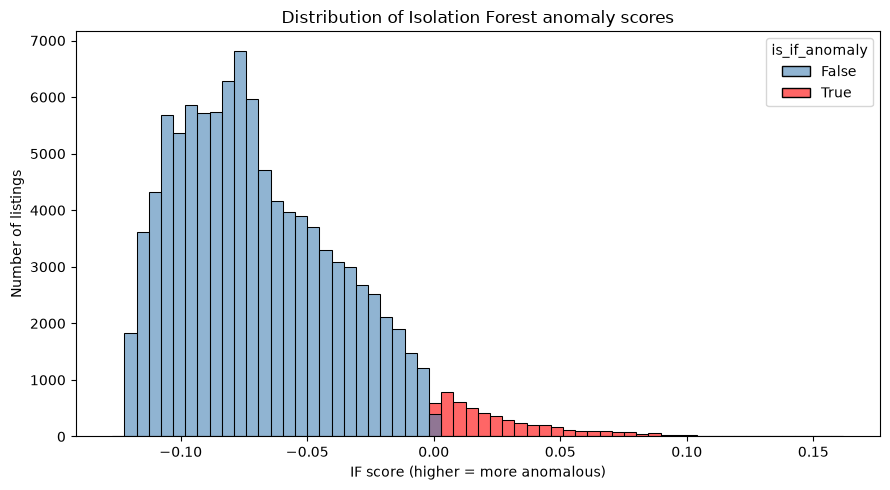

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_results, x='if_score', hue='is_if_anomaly', bins=60,
             palette={True: 'red', False: 'steelblue'}, alpha=0.6, ax=ax)
ax.set_title('Distribution of Isolation Forest anomaly scores')
ax.set_xlabel('IF score (higher = more anomalous)')
ax.set_ylabel('Number of listings')
plt.tight_layout()
plt.savefig(FIG_DIR / "if_score_distribution.png", dpi=150)
plt.show()


### 3.2 LOF score distribution

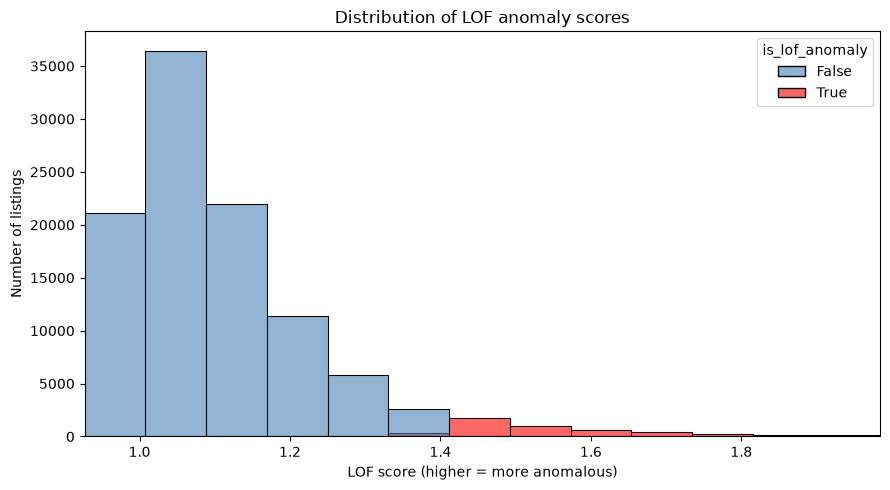

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_results, x='lof_score', hue='is_lof_anomaly', bins=60,
             palette={True: 'red', False: 'steelblue'}, alpha=0.6, ax=ax)
ax.set_xlim(df_results['lof_score'].min(), df_results['lof_score'].quantile(0.995))
ax.set_title('Distribution of LOF anomaly scores')
ax.set_xlabel('LOF score (higher = more anomalous)')
ax.set_ylabel('Number of listings')
plt.tight_layout()
plt.savefig(FIG_DIR / "lof_score_distribution.png", dpi=150)
plt.show()


### 3.3 Comparison of score distributions

**Important:** `if_score` and `lof_score` are **not on a comparable scale** 
comparing raw values (e.g. `if_score > lof_score`) would be meaningless. What can
legitimately be compared across models is **ranking**, **percentiles**, **top-k
membership**, and the **anomaly/normal label**. Rank-based comparisons are done in
Sections 4 and 5.


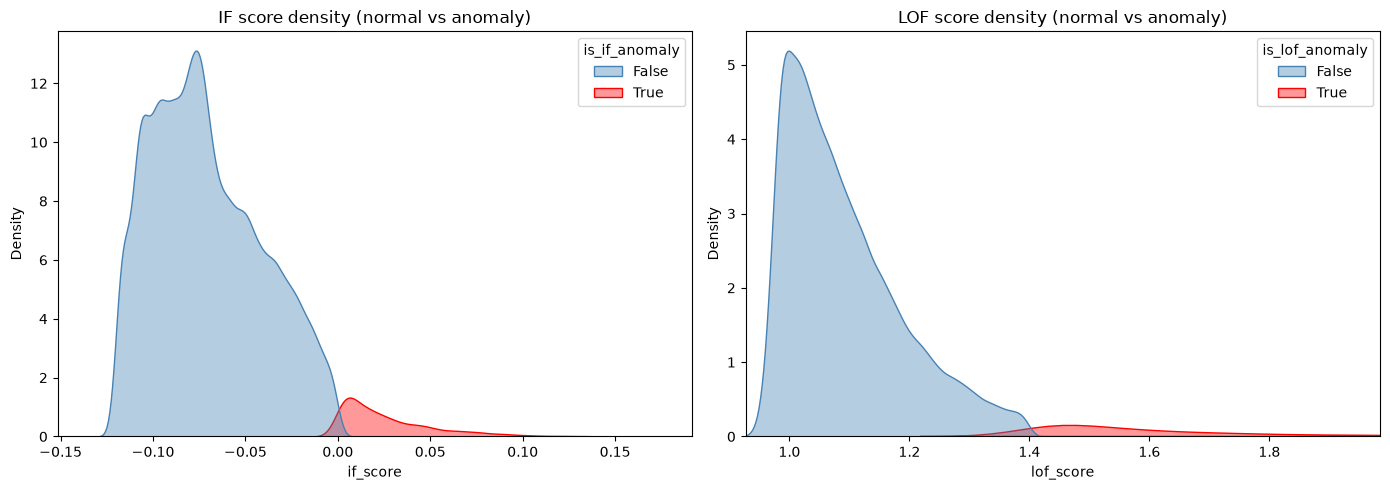

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=df_results, x='if_score', hue='is_if_anomaly',
            palette={True: 'red', False: 'steelblue'}, ax=axes[0], fill=True, alpha=0.4)
axes[0].set_title('IF score density (normal vs anomaly)')

sns.kdeplot(data=df_results, x='lof_score', hue='is_lof_anomaly',
            palette={True: 'red', False: 'steelblue'}, ax=axes[1], fill=True, alpha=0.4)
axes[1].set_xlim(df_results['lof_score'].min(), df_results['lof_score'].quantile(0.995))
axes[1].set_title('LOF score density (normal vs anomaly)')

plt.tight_layout()
plt.savefig(FIG_DIR / "model_score_correlation.png", dpi=150)
plt.show()


IF score separates normal/anomaly with a smoother, more continuous cut-off, while LOF anomalies typically sit in a longer, thinner right tail. It is consistent with LOF flagging locally isolated points rather than globally extreme ones.

## 4. Agreement between Isolation Forest and LOF

### 4.1 Confusion matrix / contingency table

In [8]:
contingency = pd.crosstab(
    df_results['is_if_anomaly'].map({True: 'IF anomaly', False: 'IF normal'}),
    df_results['is_lof_anomaly'].map({True: 'LOF anomaly', False: 'LOF normal'})
)
display(contingency)


is_lof_anomaly,LOF anomaly,LOF normal
is_if_anomaly,,
IF anomaly,370,4861
IF normal,4871,94486


### 4.2 Overlap of detected anomalies

In [9]:
if_anomalies_ids = set(df_results.loc[df_results['is_if_anomaly'], 'id'])
lof_anomalies_ids = set(df_results.loc[df_results['is_lof_anomaly'], 'id'])

intersection = if_anomalies_ids & lof_anomalies_ids
union = if_anomalies_ids | lof_anomalies_ids
if_only = if_anomalies_ids - lof_anomalies_ids
lof_only = lof_anomalies_ids - if_anomalies_ids

jaccard = len(intersection) / len(union) if union else np.nan

print(f"IF anomalies:        {len(if_anomalies_ids):,}")
print(f"LOF anomalies:       {len(lof_anomalies_ids):,}")
print(f"Intersection (both): {len(intersection):,}")
print(f"Union:               {len(union):,}")
print(f"IF-only:             {len(if_only):,}")
print(f"LOF-only:            {len(lof_only):,}")
print(f"Jaccard similarity:  {jaccard:.4f}")


IF anomalies:        5,206
LOF anomalies:       5,203
Intersection (both): 367
Union:               10,042
IF-only:             4,839
LOF-only:            4,836
Jaccard similarity:  0.0365


### 4.3 Visualisation of agreement

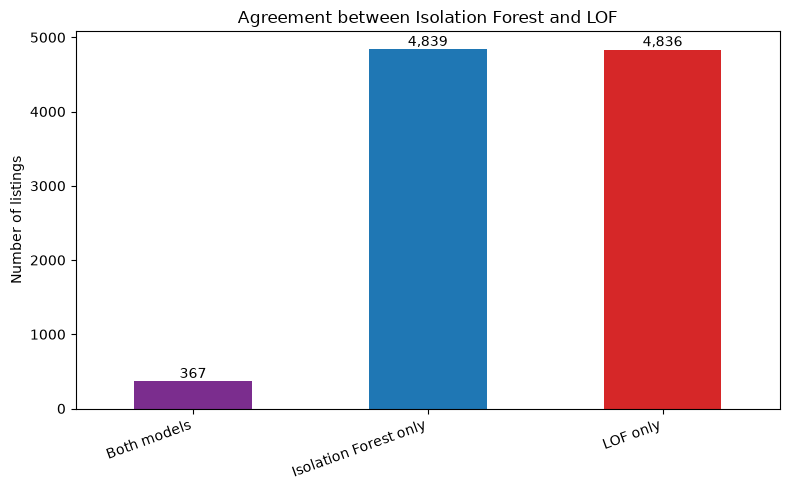

,n_listings
Both models,367
Isolation Forest only,4839
LOF only,4836


In [10]:
agreement_counts = pd.Series({
    'Both models': len(intersection),
    'Isolation Forest only': len(if_only),
    'LOF only': len(lof_only)
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#7b2d8e', '#1f77b4', '#d62728']
agreement_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Agreement between Isolation Forest and LOF')
ax.set_ylabel('Number of listings')
for i, v in enumerate(agreement_counts):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / "model_agreement.png", dpi=150)
plt.show()

display(agreement_counts.to_frame("n_listings"))


## 5. Relationship between model scores

### 5.1 Score correlation

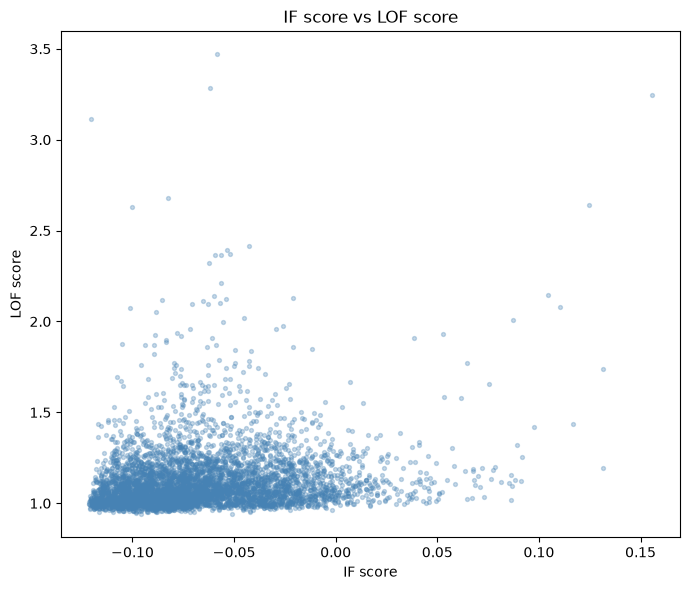

Pearson correlation:  0.1599 (p=0.00e+00)
Spearman correlation: 0.2222 (p=0.00e+00)


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
sample = df_results.sample(min(5000, len(df_results)), random_state=42)
ax.scatter(sample['if_score'], sample['lof_score'], s=8, alpha=0.3, color='steelblue')
ax.set_xlabel('IF score')
ax.set_ylabel('LOF score')
ax.set_title('IF score vs LOF score')
plt.tight_layout()
plt.show()

pearson_r, pearson_p = stats.pearsonr(df_results['if_score'], df_results['lof_score'])
spearman_r, spearman_p = stats.spearmanr(df_results['if_score'], df_results['lof_score'])

print(f"Pearson correlation:  {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman correlation: {spearman_r:.4f} (p={spearman_p:.2e})")


Spearman is the more meaningful figure here: it asks whether the two models produce a similar RANKING of anomalousness, not whether their raw scores agree in magnitude.

### 5.2 Rank correlation

In [12]:
df_results['if_rank'] = df_results['if_score'].rank(ascending=False)
df_results['lof_rank'] = df_results['lof_score'].rank(ascending=False)

rank_corr, rank_p = stats.spearmanr(df_results['if_rank'], df_results['lof_rank'])
print(f"Spearman correlation between if_rank and lof_rank: {rank_corr:.4f} (p={rank_p:.2e})")


Spearman correlation between if_rank and lof_rank: 0.2222 (p=0.00e+00)


This is mathematically equivalent to the Spearman correlation on raw scores above, shown explicitly via ranks for clarity and for reuse in Section 11.

## 6. Characterisation of detected anomalies

Define the working subsets and a small helper to recover a categorical variable even if it was one-hot encoded upstream


In [13]:
df_if = df_results[df_results['is_if_anomaly']]
df_lof = df_results[df_results['is_lof_anomaly']]
df_both = df_results[df_results['is_if_anomaly'] & df_results['is_lof_anomaly']]

print(f"IF anomalies:       {len(df_if):,}")
print(f"LOF anomalies:      {len(df_lof):,}")
print(f"Both (consensus):   {len(df_both):,}")


def get_categorical(frame, prefix):
    if prefix in frame.columns:
        return frame[prefix]
    dummy_cols = [c for c in frame.columns if c.startswith(f"{prefix}_")]
    if dummy_cols:
        return frame[dummy_cols].idxmax(axis=1).str.replace(f"{prefix}_", "", regex=False)
    return None


def category_distribution(prefix, label):
    full_cat = get_categorical(df_results, prefix)
    if full_cat is None:
        print(f"[skipped] '{prefix}' not found as a column or as one-hot dummies in model_results_full.csv")
        return None

    dist = pd.DataFrame({
        'Full dataset (%)': full_cat.value_counts(normalize=True) * 100,
        'IF anomalies (%)': get_categorical(df_if, prefix).value_counts(normalize=True) * 100,
        'LOF anomalies (%)': get_categorical(df_lof, prefix).value_counts(normalize=True) * 100,
        'Both (%)': get_categorical(df_both, prefix).value_counts(normalize=True) * 100,
    }).round(2).fillna(0.0)
    dist = dist.sort_values('Full dataset (%)', ascending=False)
    print(f"\n{label} distribution: dataset vs anomalies (%)")
    display(dist)
    return dist


IF anomalies:       5,231
LOF anomalies:      5,241
Both (consensus):   370


### 6.1 Property type

In [14]:
property_type_dist = category_distribution('property_type', 'Property type')



Property type distribution: dataset vs anomalies (%)


,Full dataset (%),IF anomalies (%),LOF anomalies (%),Both (%)
property_type,,,,
Apartamento,59.70,6.94,51.88,10.54
Casa o chalet,17.09,22.27,4.96,17.84
Villa,7.59,29.42,4.62,22.70
Hotel,6.05,6.79,6.53,3.78
Casa rural,2.78,10.36,7.77,9.19
Hostal o pensión,2.60,7.30,4.64,10.00
Apartahotel,1.08,1.36,7.37,2.97
Chalet de montaña,0.74,2.70,3.21,2.70
Albergue,0.63,5.22,0.82,6.49


### 6.2 Region

In [15]:
region_dist = category_distribution('region', 'Region')



Region distribution: dataset vs anomalies (%)


,Full dataset (%),IF anomalies (%),LOF anomalies (%),Both (%)
region,,,,
Andalucía,29.30,12.96,29.42,15.95
Canary Islands,14.95,6.23,13.99,3.78
Comunidad Valenciana,13.58,8.47,10.78,10.00
Cataluña,12.04,14.07,11.41,11.62
Galicia,5.18,4.76,4.37,5.68
Islas Baleares,4.16,15.48,3.13,14.59
Castilla y León,3.47,9.92,3.30,8.92
Comunidad de Madrid,3.31,5.01,3.05,6.76
Región de Murcia,2.40,2.50,2.25,2.70


## 7. Numerical characteristics of anomalies

Compare medians of the main numeric variables across groups. The median is used
throughout given the strongly skewed distributions already observed for price and
surface area. Only variables actually present in `model_results_full.csv` are
included.


In [16]:
candidate_vars = [
    'log_price', 'log_sqm', 'num_rooms', 'num_bathrooms',
    'price_per_sqm', 'sqm_per_room', 'baths_per_room', 'discount_pct',
    'price_relative_to_type', 'price_relative_to_province'
]
numeric_vars = [v for v in candidate_vars if v in df_results.columns]
missing_vars = [v for v in candidate_vars if v not in df_results.columns]
if missing_vars:
    print(f"[note] Not present in model_results_full.csv, skipped: {missing_vars}")

numeric_profile = pd.DataFrame({
    'Dataset (median)': df_results[numeric_vars].median(),
    'IF (median)': df_if[numeric_vars].median(),
    'LOF (median)': df_lof[numeric_vars].median(),
    'Both (median)': df_both[numeric_vars].median(),
}).round(3)
display(numeric_profile)


,Dataset (median),IF (median),LOF (median),Both (median)
log_price,6.808,8.067,6.649,8.118
log_sqm,4.263,5.303,4.078,4.696
num_rooms,2.000,4.000,1.000,2.000
num_bathrooms,1.000,3.000,1.000,2.000
price_per_sqm,12.720,16.734,13.420,28.346
sqm_per_room,0.000,0.000,0.000,0.075
baths_per_room,0.000,0.000,0.000,0.217
discount_pct,0.073,0.067,0.071,0.068
price_relative_to_type,0.999,2.444,0.906,3.154
price_relative_to_province,1.000,3.046,0.872,3.035


## 8. Anomaly rates by segment

Rather than asking *"which category has the most anomalies?"*, we are focused on *"what percentage of each category is flagged as
anomalous?"*.


In [17]:
def anomaly_rate_by_segment(prefix, label, min_n=0):
    cat = get_categorical(df_results, prefix)
    if cat is None:
        print(f"[skipped] '{prefix}' not found.")
        return None
    tmp = pd.DataFrame({
        prefix: cat,
        'is_if_anomaly': df_results['is_if_anomaly'],
        'is_lof_anomaly': df_results['is_lof_anomaly'],
    })
    grouped = tmp.groupby(prefix).agg(
        Total=('is_if_anomaly', 'size'),
        IF_anomalies=('is_if_anomaly', 'sum'),
        LOF_anomalies=('is_lof_anomaly', 'sum'),
    )
    grouped = grouped[grouped['Total'] >= min_n].copy()
    grouped['IF_rate'] = (grouped['IF_anomalies'] / grouped['Total'] * 100).round(2)
    grouped['LOF_rate'] = (grouped['LOF_anomalies'] / grouped['Total'] * 100).round(2)
    grouped = grouped.sort_values('IF_rate', ascending=False)
    print(f"\nAnomaly rate by {label} (min n={min_n})")
    display(grouped)
    return grouped


In [18]:
property_type_rates = anomaly_rate_by_segment('property_type', 'property type')



Anomaly rate by property type (min n=0)


,Total,IF_anomalies,LOF_anomalies,IF_rate,LOF_rate
property_type,,,,,
Posada u hostería,136,103,13,75.74,9.56
Albergue,654,273,43,41.74,6.57
Habitación en casa particular,503,120,67,23.86,13.32
Bed and breakfast,580,118,66,20.34,11.38
Villa,7936,1539,242,19.39,3.05
Casa rural,2906,542,407,18.65,14.01
Chalet de montaña,776,141,168,18.17,21.65
Camping,240,34,93,14.17,38.75
Hostal o pensión,2720,382,243,14.04,8.93


In [19]:
region_rates = anomaly_rate_by_segment('region', 'region')



Anomaly rate by region (min n=0)


,Total,IF_anomalies,LOF_anomalies,IF_rate,LOF_rate
region,,,,,
Islas Baleares,4349,810,164,18.62,3.77
Castilla-La Mancha,1885,273,152,14.48,8.06
Castilla y León,3627,519,173,14.31,4.77
País Vasco,1989,239,78,12.02,3.92
Cantabria,1849,181,78,9.79,4.22
Aragón,1567,125,87,7.98,5.55
Comunidad de Madrid,3467,262,160,7.56,4.61
Comunidad Foral de Navarra,687,49,102,7.13,14.85
Principado de Asturias,2464,148,214,6.01,8.69


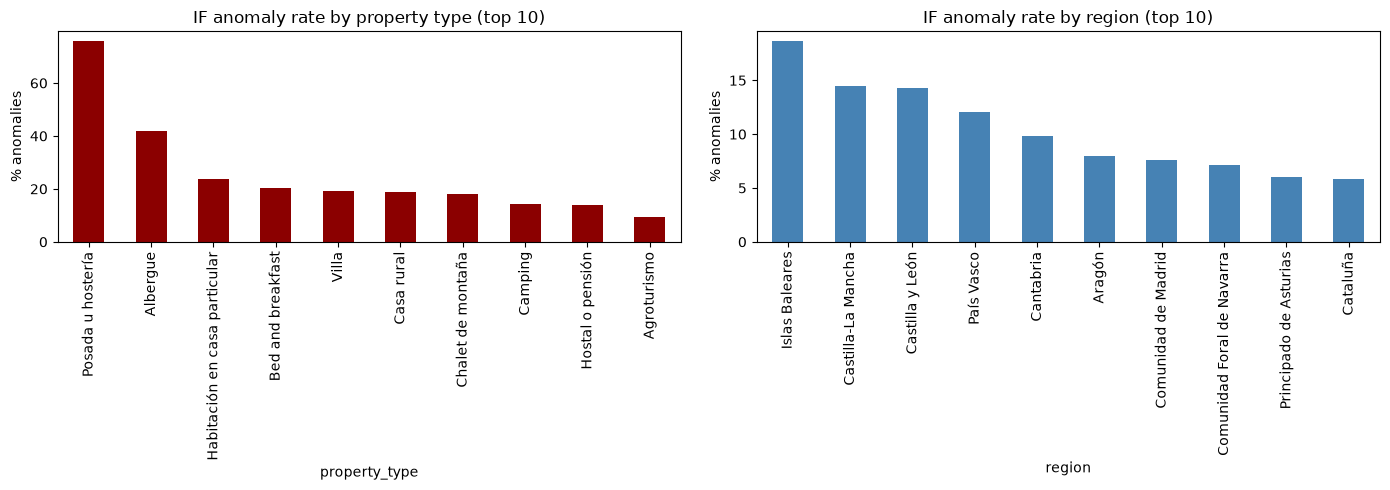

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if property_type_rates is not None:
    property_type_rates['IF_rate'].sort_values(ascending=False).head(10).plot(kind='bar', color='darkred', ax=axes[0])
    axes[0].set_title('IF anomaly rate by property type (top 10)')
    axes[0].set_ylabel('% anomalies')
if region_rates is not None:
    region_rates['IF_rate'].sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue', ax=axes[1])
    axes[1].set_title('IF anomaly rate by region (top 10)')
    axes[1].set_ylabel('% anomalies')
plt.tight_layout()
plt.savefig(FIG_DIR / "IF_anomalies_by_property_type.png", dpi=150)
plt.show()


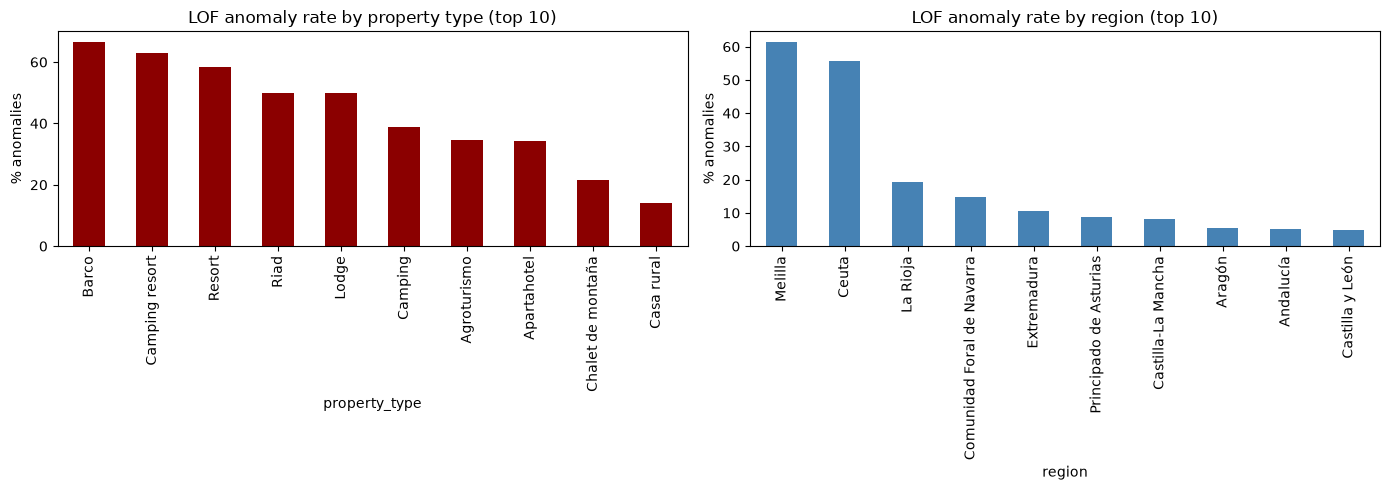

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if property_type_rates is not None:
    property_type_rates['LOF_rate'].sort_values(ascending=False).head(10).plot(kind='bar', color='darkred', ax=axes[0])
    axes[0].set_title('LOF anomaly rate by property type (top 10)')
    axes[0].set_ylabel('% anomalies')
if region_rates is not None:
    region_rates['LOF_rate'].sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue', ax=axes[1])
    axes[1].set_title('LOF anomaly rate by region (top 10)')
    axes[1].set_ylabel('% anomalies')
plt.tight_layout()
plt.savefig(FIG_DIR / "LOF_anomalies_by_property_type.png", dpi=150)
plt.show()


## 9. Business-rule validation

Business-rule flags (`extreme_price_high`, `extreme_price_low`,
`suspected_placeholder_sqm`, `extreme_price_per_sqm`, `excess_bathrooms`,
`tiny_villa`, `huge_apartment`, ...) were deliberately **excluded from `X`** in
the training models notebook to avoid leakage. They are loaded here only as an **external reference**
to see how much the unsupervised models agree with hand-crafted heuristics, not as
ground truth.

For each rule we report two different overlap measures:
- **Coverage**: of the listings flagged by the rule, what % was also flagged by the model.
- **Overlap rate**: of the listings flagged by the model, what % also matches the rule.

Neither is called "precision" or "recall" in the strict sense, since there is no
ground truth for anomalies.


In [22]:
business_rules_path = Path("data/business_rule_flags.csv")  # adjust path if different
business_rule_cols = [
    'extreme_price_high', 'extreme_price_low', 'suspected_placeholder_sqm',
    'extreme_price_per_sqm', 'excess_bathrooms', 'tiny_villa', 'huge_apartment'
]

if business_rules_path.exists():
    df_rules = pd.read_csv(business_rules_path)
    df_rules['id'] = df_rules['id'].astype(str)
    df_results['id'] = df_results['id'].astype(str)
    df_merged = df_results.merge(df_rules[['id'] + [c for c in business_rule_cols if c in df_rules.columns]],
                                  on='id', how='left')
    available_rules = [c for c in business_rule_cols if c in df_merged.columns]
else:
    print(f"[skipped] Business-rule file not found at {business_rules_path}. "
          f"Update the path once the rules file location is confirmed.")
    df_merged = df_results.copy()
    available_rules = []

print(f"Business rules available for validation: {available_rules}")


[skipped] Business-rule file not found at data\business_rule_flags.csv. Update the path once the rules file location is confirmed.
Business rules available for validation: []


### 9.1 Model anomalies vs business rules

In [23]:
if available_rules:
    overlap_rows = []
    for rule in available_rules:
        rule_flagged = df_merged[df_merged[rule] == 1]
        n_rule = len(rule_flagged)

        if_coverage = rule_flagged['is_if_anomaly'].mean() * 100 if n_rule else np.nan
        lof_coverage = rule_flagged['is_lof_anomaly'].mean() * 100 if n_rule else np.nan
        both_coverage = (rule_flagged['is_if_anomaly'] & rule_flagged['is_lof_anomaly']).mean() * 100 if n_rule else np.nan

        if_flagged = df_merged[df_merged['is_if_anomaly']]
        lof_flagged = df_merged[df_merged['is_lof_anomaly']]
        both_flagged = df_merged[df_merged['is_if_anomaly'] & df_merged['is_lof_anomaly']]

        if_overlap_rate = if_flagged[rule].mean() * 100 if len(if_flagged) else np.nan
        lof_overlap_rate = lof_flagged[rule].mean() * 100 if len(lof_flagged) else np.nan
        both_overlap_rate = both_flagged[rule].mean() * 100 if len(both_flagged) else np.nan

        overlap_rows.append({
            'Business rule': rule, 'n_flagged_by_rule': n_rule,
            'IF coverage (%)': round(if_coverage, 1), 'LOF coverage (%)': round(lof_coverage, 1),
            'Both coverage (%)': round(both_coverage, 1),
            'IF overlap rate (%)': round(if_overlap_rate, 1), 'LOF overlap rate (%)': round(lof_overlap_rate, 1),
            'Both overlap rate (%)': round(both_overlap_rate, 1),
        })

    business_rule_overlap = pd.DataFrame(overlap_rows)
    display(business_rule_overlap)
else:
    business_rule_overlap = pd.DataFrame()
    print("No business-rule columns available: skipping overlap table.")


No business-rule columns available: skipping overlap table.


## 10. Consensus anomalies

Observations **consistently identified as anomalous by both methods** (not to be
described as "true anomalies", since there is no ground truth).


In [24]:
df_results['consensus_anomaly'] = df_results['is_if_anomaly'] & df_results['is_lof_anomaly']
df_results['agreement_group'] = np.select(
    [
        df_results['is_if_anomaly'] & df_results['is_lof_anomaly'],
        df_results['is_if_anomaly'] & ~df_results['is_lof_anomaly'],
        ~df_results['is_if_anomaly'] & df_results['is_lof_anomaly'],
    ],
    ['Both', 'IF only', 'LOF only'],
    default='Neither'
)

display(df_results['agreement_group'].value_counts().to_frame('n_listings'))
consensus_anomalies = df_results[df_results['consensus_anomaly']].copy()


,n_listings
agreement_group,
Neither,94486
LOF only,4871
IF only,4861
Both,370


## 11. Ranking of the most anomalous observations

In [25]:
display_cols = [c for c in ['id', 'name', 'property_type', 'province', 'sqm', 'price',
                             'price_per_sqm', 'if_score', 'lof_score'] if c in df_results.columns or c in ['property_type', 'province']]
# resolve property_type/province if they only exist as dummies
for cat_col in ['property_type', 'province']:
    if cat_col not in df_results.columns:
        resolved = get_categorical(df_results, cat_col)
        if resolved is not None:
            df_results[cat_col] = resolved
display_cols = [c for c in ['id', 'name', 'property_type', 'province', 'sqm', 'price',
                             'price_per_sqm', 'if_score', 'lof_score'] if c in df_results.columns]


### 11.1 Top Isolation Forest anomalies

In [26]:
top_if_anomalies = df_results.sort_values('if_score', ascending=False).head(20)[display_cols]
display(top_if_anomalies)


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
41653,15099395,The Haven,Villa,Málaga,200.0,49973.0000,249.865000,0.161898,1.819166
94481,8841824,Atalya Rio Verde,Villa,Málaga,15.0,68425.0001,4561.666673,0.155568,3.248562
77168,5700550,"MAS DEL VENT- Barbacoa, jardín, piscina privad...",Casa o chalet,Tarragona,12.0,70120.0200,5843.335000,0.148826,3.872021
53913,16666796,Casa Mil Flores,Villa,Málaga,18.0,65362.7200,3631.262222,0.146501,2.717439
80041,6464926,Torre d'en Bru,Casa rural,Barcelona,12.0,10027.0201,835.585008,0.143906,1.856431
85294,742701,Can Micos - Masía de grupos 16 hasta 25 personas,Casa rural,Gerona,23.0,4860.5000,211.326087,0.138860,1.292006
61858,2326634,Casa Rural La Calzada,Casa rural,Salamanca,15.0,4977.0001,331.800007,0.136817,1.158117
85327,7431168,Villa Palmview Up To 28 Guests Close To Jávea ...,Villa,Alicante,10.0,9701.7500,970.175000,0.136250,3.154472
51620,16413490,Finca las Mellizas LUXURY VILLA junto a Madrid,Villa,Toledo,12.0,7587.2727,632.272725,0.136064,1.944841
81949,6826201,Mas de Mingall,Casa rural,Tarragona,180.0,56020.0200,311.222333,0.135572,1.322853


### 11.2 Top LOF anomalies

In [27]:
top_lof_anomalies = df_results.sort_values('lof_score', ascending=False).head(20)[display_cols]
display(top_lof_anomalies)


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
44191,15463368,Lemon Hostel Altea habitaciones privadas y com...,Albergue,Alicante,72.0,574.4500,7.978472,0.009374,5.772970
34404,14184272,ESPECTACULAR PISO EN PALACIO Preferiblemente f...,Apartamento,Cádiz,120.0,349500.0000,2912.500000,0.069562,5.595064
64205,272511,Albergue Inturjoven Jaen,Albergue,Jaén,40.0,467.0001,11.675002,-0.077175,5.337278
53203,16607211,Can Guash,Casa o chalet,Ibiza y Formentera,950.0,17170.8000,18.074526,0.135000,5.162640
55741,16835101,Bloom House,Casa o chalet,Castellón,72.0,349500.0000,4854.166667,0.095227,5.096995
36515,14414644,Villa Ariel,Casa o chalet,Gerona,859.0,2618.0200,3.047753,0.045992,5.003142
47806,15923,Hostal Europa,Posada u hostería,Principado de Asturias,35.0,485.0000,13.857143,-0.049305,4.714192
21186,12603534,Atlanterra Villas & Apartamentos,Apartamento,Cádiz,60.0,97.7401,1.629002,-0.002342,4.646152
75621,5350138,"Sur Suites La Dorada, centricos soleados a poc...",Apartahotel,Málaga,65.0,598.0000,9.200000,-0.054999,4.441192
5823,10732622,Vivienda Rural El Peñón de Los Primillas,Chalet de montaña,Jaén,50.0,641.2501,12.825002,-0.068352,4.166197


### 11.3 Top consensus anomalies

IF and LOF scores are not directly comparable in magnitude (Section 3.3), so a
joint ranking is built from **percentiles** of each score rather than raw values.


In [28]:
df_results['if_percentile'] = df_results['if_score'].rank(pct=True) * 100
df_results['lof_percentile'] = df_results['lof_score'].rank(pct=True) * 100
df_results['combined_rank'] = (df_results['if_percentile'] + df_results['lof_percentile']) / 2

consensus_anomalies = df_results[df_results['consensus_anomaly']].copy()
top_consensus_anomalies = consensus_anomalies.sort_values('combined_rank', ascending=False).head(20)[
    display_cols + ['if_percentile', 'lof_percentile', 'combined_rank']
]
display(top_consensus_anomalies)


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score,if_percentile,lof_percentile,combined_rank
53203,16607211,Can Guash,Casa o chalet,Ibiza y Formentera,950.0,17170.8000,18.074526,0.135000,5.162640,99.990439,99.997132,99.993785
77168,5700550,"MAS DEL VENT- Barbacoa, jardín, piscina privad...",Casa o chalet,Tarragona,12.0,70120.0200,5843.335000,0.148826,3.872021,99.998088,99.987570,99.992829
94481,8841824,Atalya Rio Verde,Villa,Málaga,15.0,68425.0001,4561.666673,0.155568,3.248562,99.999044,99.968448,99.983746
85327,7431168,Villa Palmview Up To 28 Guests Close To Jávea ...,Villa,Alicante,10.0,9701.7500,970.175000,0.136250,3.154472,99.993307,99.966535,99.979921
82786,6970731,Private Estate for Groups Pool and Sports,Villa,Tarragona,10.0,8639.5200,863.952000,0.121853,3.353658,99.968448,99.975141,99.971794
53913,16666796,Casa Mil Flores,Villa,Málaga,18.0,65362.7200,3631.262222,0.146501,2.717439,99.997132,99.911080,99.954106
55741,16835101,Bloom House,Casa o chalet,Castellón,72.0,349500.0000,4854.166667,0.095227,5.096995,99.877615,99.996175,99.936895
51477,16388850,Villa lujo con vista al mar - 10 pers. - ES-17...,Villa,Málaga,700.0,19578.0200,27.968600,0.124852,2.640089,99.975141,99.894825,99.934983
36958,14461693,Casa Rural Abuela Carolina,Chalet de montaña,Zamora,98.0,245000.0000,2500.000000,0.091746,3.619877,99.853712,99.982790,99.918251
67411,3385144,Hotel Rural Don Burguillo,Hotel,Ávila,40.5,8950.0000,220.987654,0.133562,2.377423,99.986614,99.816423,99.901518


## 12. Case studies

A handful of representative cases, selected programmatically. Interpret the actual
listing details once this cell is run on the real data, the selection logic is
what matters here, not fixed numbers.


In [29]:
case_studies = {}

if 'price_per_sqm' in df_results.columns:
    case_studies['Case 1: Extreme price per square metre'] = df_results.sort_values('price_per_sqm', ascending=False).head(3)

if {'baths_per_room', 'sqm_per_room'}.issubset(df_results.columns):
    structural_outlier_score = df_results['baths_per_room'].abs() + df_results['sqm_per_room'].abs()
    case_studies['Case 2: Unusual accommodation structure'] = (
        df_results.assign(_structural_score=structural_outlier_score)
                  .sort_values('_structural_score', ascending=False).head(3)
                  .drop(columns='_structural_score')
    )

if 'price_relative_to_type' in df_results.columns:
    case_studies['Case 3: Contextual anomaly (relative to type/province)'] = (
        df_results[df_results['is_if_anomaly'] | df_results['is_lof_anomaly']]
        .sort_values('price_relative_to_type', ascending=False).head(3)
    )

for title, frame in case_studies.items():
    print(f"\n{'='*80}\n{title}\n{'='*80}")
    display(frame[display_cols])



Case 1: Extreme price


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
34404,14184272,ESPECTACULAR PISO EN PALACIO Preferiblemente f...,Apartamento,Cádiz,120.0,349500.0,2912.500000,0.069562,5.595064
55741,16835101,Bloom House,Casa o chalet,Castellón,72.0,349500.0,4854.166667,0.095227,5.096995
36958,14461693,Casa Rural Abuela Carolina,Chalet de montaña,Zamora,98.0,245000.0,2500.000000,0.091746,3.619877



Case 2: Extreme price per square metre


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
77168,5700550,"MAS DEL VENT- Barbacoa, jardín, piscina privad...",Casa o chalet,Tarragona,12.0,70120.0200,5843.335000,0.148826,3.872021
55741,16835101,Bloom House,Casa o chalet,Castellón,72.0,349500.0000,4854.166667,0.095227,5.096995
94481,8841824,Atalya Rio Verde,Villa,Málaga,15.0,68425.0001,4561.666673,0.155568,3.248562



Case 3: Unusual accommodation structure


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
53021,16593338,Lets Holidays APARTMENT NEAR THE BEACH,Apartamento,Gerona,58.0,1103.40,19.024138,-0.102094,1.015056
39957,14843536,Apartamento moderno con parking incluido,Apartamento,Vizcaya,65.0,1249.50,19.223077,-0.048660,1.159453
51297,16350407,A1148 - Atrium Beach 3 - 2004 Finestrat,Apartamento,Alicante,90.0,893.27,9.925222,-0.097209,0.992653



Case 4: Contextual anomaly (relative to type/province)


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
34404,14184272,ESPECTACULAR PISO EN PALACIO Preferiblemente f...,Apartamento,Cádiz,120.0,349500.0,2912.500000,0.069562,5.595064
55741,16835101,Bloom House,Casa o chalet,Castellón,72.0,349500.0,4854.166667,0.095227,5.096995
39877,14831276,"Precioso piso en calle Yeseros, en Albayzín",Apartamento,Granada,60.0,214445.0,3574.083333,0.035099,3.123644


## 13. Interesting disagreement cases

Listings flagged by only one of the two models. These help illustrate the
conceptual difference between the algorithms. **Isolation Forest** isolates
observations that are globally rare, while **LOF** flags observations that are
locally sparse relative to their neighbourhood. No claim is made about which
method is "correct"; the goal is to understand *why* they can disagree.


In [30]:
if_only_cases = df_results[df_results['agreement_group'] == 'IF only'].sort_values('if_score', ascending=False).head(10)
lof_only_cases = df_results[df_results['agreement_group'] == 'LOF only'].sort_values('lof_score', ascending=False).head(10)

print("IF-only cases (top 10 by if_score):")
display(if_only_cases[display_cols])

print("\nLOF-only cases (top 10 by lof_score):")
display(lof_only_cases[display_cols])


IF-only cases (top 10 by if_score):


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
85294,742701,Can Micos - Masía de grupos 16 hasta 25 personas,Casa rural,Gerona,23.0,4860.5000,211.326087,0.138860,1.292006
61858,2326634,Casa Rural La Calzada,Casa rural,Salamanca,15.0,4977.0001,331.800007,0.136817,1.158117
81949,6826201,Mas de Mingall,Casa rural,Tarragona,180.0,56020.0200,311.222333,0.135572,1.322853
46891,15822608,Villa Meraki experiencia,Casa o chalet,Ávila,17.0,6414.5473,377.326312,0.134606,1.156369
67791,3479363,Eira Ski Lodge,Hotel,Lérida,50.0,30324.4201,606.488402,0.132605,1.387730
56931,16951551,Oasis Beach House,Casa o chalet,Málaga,28.0,14695.5500,524.841071,0.132265,1.301258
76997,5661934,La Casona de los Cinco Caños,Casa o chalet,Segovia,14.0,5737.9601,409.854293,0.131440,1.192246
43553,15368612,Ganekobide,Chalet de montaña,Álava,15.0,4601.7600,306.784000,0.128644,1.117359
62203,2383866,Villa Juan Carlos,Casa o chalet,Mallorca,700.0,21288.4700,30.412100,0.126223,1.168105
94162,8802338,La Ermita de los Llanos,Casa rural,Ávila,12.0,5950.0000,495.833333,0.124139,1.386227



LOF-only cases (top 10 by lof_score):


,id,name,property_type,province,sqm,price,price_per_sqm,if_score,lof_score
64205,272511,Albergue Inturjoven Jaen,Albergue,Jaén,40.0,467.0001,11.675002,-0.077175,5.337278
47806,15923,Hostal Europa,Posada u hostería,Principado de Asturias,35.0,485.0000,13.857143,-0.049305,4.714192
21186,12603534,Atlanterra Villas & Apartamentos,Apartamento,Cádiz,60.0,97.7401,1.629002,-0.002342,4.646152
75621,5350138,"Sur Suites La Dorada, centricos soleados a poc...",Apartahotel,Málaga,65.0,598.0000,9.200000,-0.054999,4.441192
5823,10732622,Vivienda Rural El Peñón de Los Primillas,Chalet de montaña,Jaén,50.0,641.2501,12.825002,-0.068352,4.166197
3400,10400276,"Casita con piscina cerca de Chinchón, Aranjuez...",Casa o chalet,Comunidad de Madrid,800.0,1226.7800,1.533475,-0.001785,3.992708
63021,252001,Vista Oasis,Camping resort,Gran Canaria,44.0,665.0000,15.113636,-0.083103,3.980215
80865,6600274,Bnbook Medea Apartments,Apartahotel,Málaga,45.0,557.0000,12.377778,-0.061546,3.939458
39390,14760289,Apartamentos Juvimar,Hostal o pensión,Lanzarote,40.0,735.0000,18.375000,-0.064184,3.682053
63360,2573178,Casa Jardin,Casa rural,Almería,40.0,652.6000,16.315000,-0.063809,3.648728


## 14. Final validation summary

In [32]:
final_summary = pd.DataFrame([
    {'Aspect': 'Dataset analysed', 'Result': f"{n_rows:,}"},
    {'Aspect': 'IF anomalies', 'Result': f"{n_if_anomalies:,} ({n_if_anomalies / n_rows:.2%})"},
    {'Aspect': 'LOF anomalies', 'Result': f"{n_lof_anomalies:,} ({n_lof_anomalies / n_rows:.2%})"},
    {'Aspect': 'Agreement (both)', 'Result': f"{len(intersection):,}"},
    {'Aspect': 'Jaccard similarity', 'Result': f"{jaccard:.4f}"},
    {'Aspect': 'IF-only', 'Result': f"{len(if_only):,}"},
    {'Aspect': 'LOF-only', 'Result': f"{len(lof_only):,}"},
    {'Aspect': 'Spearman rank correlation (IF vs LOF)', 'Result': f"{rank_corr:.4f}"},
    {'Aspect': 'Business-rule overlap', 'Result': "see Section 9" if available_rules else "not available"},
])
display(final_summary)


,Aspect,Result
0,Dataset analysed,"104,588"
1,IF anomalies,"5,231 (5.00%)"
2,LOF anomalies,"5,241 (5.01%)"
3,Agreement (both),367
4,Jaccard similarity,0.0365
5,IF-only,"4,839"
6,LOF-only,"4,836"
7,Spearman rank correlation (IF vs LOF),0.2222
8,Business-rule overlap,not available


The results show that both algorithms identify a subset of observations with
characteristics that differ from the general accommodation population. The
agreement between Isolation Forest and LOF provides an additional indication of
consistency, while the disagreement between both methods highlights observations
whose anomalous nature depends on the detection perspective. The comparison with
business rules further provides an interpretable reference for assessing whether
detected observations correspond to extreme prices, unusual accommodation
characteristics, or contextual deviations.


## 15. Export results

Save the reusable tables produced above so the write-up (and any further
exploration) does not require re-running the full notebook.


In [33]:
exports = {
    'anomaly_analysis_summary.csv': final_summary,
    'anomaly_model_comparison.csv': summary_table,
    'anomaly_by_property_type.csv': property_type_rates,
    'anomaly_by_region.csv': region_rates,
    'business_rule_overlap.csv': business_rule_overlap,
    'top_if_anomalies.csv': top_if_anomalies,
    'top_lof_anomalies.csv': top_lof_anomalies,
    'consensus_anomalies.csv': consensus_anomalies,
    'disagreement_cases.csv': pd.concat([if_only_cases.assign(disagreement_type='IF only'),
                                          lof_only_cases.assign(disagreement_type='LOF only')]),
}

print("=" * 60)
print("EXPORTING RESULTS")
print("=" * 60)
for filename, frame in exports.items():
    if frame is None or (hasattr(frame, 'empty') and frame.empty):
        print(f"\u26a0\ufe0f  Skipped (no data): {filename}")
        continue
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=False)
    print(f"Saved: {path}")


EXPORTING RESULTS
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\anomaly_analysis_summary.csv
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\anomaly_model_comparison.csv
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\anomaly_by_property_type.csv
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\anomaly_by_region.csv
⚠️  Skipped (no data): business_rule_overlap.csv
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\top_if_anomalies.csv
Saved: c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\6. Automated pipeline\data\results\top_l